In [1]:
from DatabankLib.protein_functions import *
import yaml

#databankPath = "/home/sosamuli/work/NMRlipids/IDPdatabank/"  # this is the local path for the cloned Databank
#os.environ["NMLDB_ROOT_PATH"] = "/home/sosamuli/work/NMRlipids/IDPdatabank/"

databankPath = "/home/sosamuli/work/NMRlipids/IDPsimBank/"  # this is the local path for the cloned Databank
os.environ["NMLDB_ROOT_PATH"] = "/home/sosamuli/work/NMRlipids/IDPsimBank/"


# These two lines include core Databank routines and Databank API
from DatabankLib.core import *
from DatabankLib.databankLibrary import *
# This is for plotting
from DatabankLib.databankio import *
from DatabankLib.plottings import plotSimulation
#from IPython.display import display, Markdown

# This initializes the databank and stores the information of all simulations into a list.
# Each list item contains the information from README.yaml file of the given simulation.
systems = initialize_databank()

/home/sosamuli/.local/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Databank initialized from the folder: /home/sosamuli/work/NMRlipids/IDPsimBank/Data/Simulations


In [84]:
def percentage_over_accuracy(accuracy,value):
    ratio = abs(value)/accuracy
    if ratio > 1:
        return ratio-1
    else:
        return 0
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
from matplotlib.colors import LinearSegmentedColormap

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
from matplotlib.colors import LinearSegmentedColormap


import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import re

def plot_quality_heatmap(data_dict, save_path, vmax=None):
    """
    Create a traffic-light style heatmap showing quality metrics for each residue and nucleus.

    Parameters
    ----------
    data_dict : dict
        Dictionary where keys are residues (e.g., "99GLN") or "Averages",
        and values are dicts mapping nuclei (e.g., "CA", "N", "Sum") to scores.

    save_path : str
        Path where the generated heatmap image will be saved.

    vmax : float, optional
        Maximum value for the color scale. If None, scale automatically to data range.
        Useful for comparing multiple heatmaps with consistent color limits.
    """

    # --- Prepare data ---
    df = pd.DataFrame(data_dict).T

    # Remove "Averages" row temporarily for sorting residues numerically
    if "Averages" in df.index:
        averages = df.loc["Averages"]
        df = df.drop("Averages")
    else:
        averages = None

    # Sort residues numerically if possible
    def residue_sort_key(name):
        if isinstance(name, str):
            match = re.match(r"(\d+)", name)
            if match:
                return int(match.group(1))
        return float("inf")

    df = df.loc[sorted(df.index, key=residue_sort_key)]

    # Add Averages back to the end
    if averages is not None:
        df.loc["Averages"] = averages

    # --- Transpose for plotting (residues on x-axis, nuclei on y-axis) ---
    df_t = df.T

    # --- Plot ---
    plt.figure(figsize=(10, 5))
    ax = sns.heatmap(
        df_t,
        cmap="RdYlGn_r",        # traffic-light color scheme (green = good, red = bad)
        cbar=True,
        linewidths=0.5,
        vmax=vmax               # 👈 fixed color scale if provided
    )
    ax.set_xlabel("Residue")
    ax.set_ylabel("Nucleus")
    ax.set_title("Quality Heatmap", fontsize=14)
    plt.xticks(rotation=90)
    plt.yticks(rotation=0)

    plt.tight_layout()
    plt.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.close()

    
import os
import yaml

def evaluate_chemical_shift_quality(system, atom_accuracies):
    """
    Evaluate chemical shift quality for a given system.

    Parameters
    ----------
    system : dict
        Dictionary containing simulation info with keys:
        - 'TRJ': trajectory identifier
        - 'ID': system ID
        - 'path': relative path to data folder
        - 'EXPERIMENT': includes 'chemical_shift' -> 'alignment_score'

    atom_accuracies : dict
        Mapping from nucleus (e.g. 'C', 'CA', 'N', ...) to accuracy thresholds.

    percentage_over_accuracy : callable
        Function taking (accuracy, rmsd_value) -> quality percentage.

    plot_quality_heatmap : callable
        Function taking (data_dict, save_path) to create and save a heatmap.

    Returns
    -------
    str
        Path to the generated quality heatmap file.
    """

    print(system["TRJ"], system["ID"], system["EXPERIMENT"]["chemical_shift"]["alignment_score"])

    # --- Set up file paths ---
    data_folder = os.path.join("../../Data/Simulations", system["path"])
    chemical_shifts_file_rmsd = os.path.join(data_folder, "chemical_shift_rmsd.yaml")

    if not os.path.exists(chemical_shifts_file_rmsd):
        print(f"⚠️ Missing file: {chemical_shifts_file_rmsd}")
        return None

    quality_evaluation_file = os.path.join(data_folder, "chemical_shift_quality.yaml")
    quality_heatmap_file = os.path.join(data_folder, "chemical_shift_quality_heatmap.png")

    # --- Initialize quality dict ---
    quality = {"Averages": {}}

    # --- Load RMSD data ---
    with open(chemical_shifts_file_rmsd) as f:
        rmsds = yaml.safe_load(f)

    # --- Compute quality measures ---
    for key in rmsds.keys():
        if key == "differences":
            for residue, values in rmsds[key].items():
                if residue not in quality:
                    quality[residue] = {}
                res_sum = 0
                for nuclei, value in values.items():
                    if value is None:
                        continue
                    accuracy = atom_accuracies.get(nuclei)
                    if accuracy is None:
                        continue
                    score = percentage_over_accuracy(accuracy, value)
                    quality[residue][nuclei] = score
                    res_sum += score
                #quality[residue]["Sum"] = res_sum
        else:
            value = rmsds[key]
            if value is None:
                continue
            accuracy = atom_accuracies.get(key)
            if accuracy is None:
                continue
            quality["Averages"][key] = percentage_over_accuracy(accuracy, value)

    # --- Write YAML output ---
    with open(quality_evaluation_file, "w") as f:
        yaml.dump(quality, f, sort_keys=True)

    # --- Generate heatmap ---
    print(f"🧩 Generating heatmap: {quality_heatmap_file}")
    plot_quality_heatmap(quality, quality_heatmap_file,2)
    print("✅ Heatmap saved successfully.")

    return quality_heatmap_file


import os
import yaml

def evaluate_spin_relaxation_quality(system, relaxation_accuracies):
    """
    Evaluate spin relaxation quality (R1, R2, hetNOE) for a given system.

    Parameters
    ----------
    system : dict
        Dictionary containing simulation info with keys:
        - 'TRJ': trajectory identifier
        - 'ID': system ID
        - 'path': relative path to data folder
        - 'EXPERIMENT': includes 'relaxation' -> 'alignment_score'

    relaxation_accuracies : dict
        Mapping from relaxation type ('R1', 'R2', 'hetNOE') to accuracy thresholds.

    percentage_over_accuracy : callable
        Function taking (accuracy, rmsd_value) -> quality percentage.

    plot_quality_heatmap : callable
        Function taking (data_dict, save_path) to create and save a heatmap.

    Returns
    -------
    str
        Path to the generated relaxation quality heatmap file.
    """

    #print(system["TRJ"], system["ID"], system["EXPERIMENT"]["spirelaxation"]["alignment_score"])

    # --- Define paths ---
    data_folder = os.path.join("../../Data/Simulations", system["path"])
    relaxation_file_rmsd = os.path.join(data_folder, "spin_relaxation_rmsd.yaml")

    if not os.path.exists(relaxation_file_rmsd):
        print(f"⚠️ Missing file: {relaxation_file_rmsd}")
        return None

    quality_file = os.path.join(data_folder, "relaxation_quality.yaml")
    heatmap_file = os.path.join(data_folder, "relaxation_quality_heatmap.png")

    # --- Initialize output dict ---
    quality = {"Averages": {}}

    # --- Load RMSD data ---
    with open(relaxation_file_rmsd) as f:
        rmsds = yaml.safe_load(f)

    # --- Compute quality measures ---
    for key in rmsds.keys():
        if key == "differences":
            for residue, values in rmsds[key].items():
                if residue not in quality:
                    quality[residue] = {}
                res_sum = 0
                for relaxation_type, value in values.items():
                    if value is None:
                        continue
                    accuracy = relaxation_accuracies.get(relaxation_type)
                    if accuracy is None:
                        continue
                    score = percentage_over_accuracy(accuracy, value)
                    quality[residue][relaxation_type] = score
                    res_sum += score
                #quality[residue]["Sum"] = res_sum
        else:
            # Average metrics (like R1, R2, hetNOE) outside of "differences"
            value = rmsds[key]
            if value is None:
                continue
            accuracy = relaxation_accuracies.get(key)
            if accuracy is None:
                continue
            quality["Averages"][key] = percentage_over_accuracy(accuracy, value)

    # --- Write YAML output ---
    with open(quality_file, "w") as f:
        yaml.dump(quality, f, sort_keys=True)

    # --- Generate heatmap ---
    print(f"🧩 Generating relaxation heatmap: {heatmap_file}")
    plot_quality_heatmap(quality, heatmap_file,3)
    print("✅ Relaxation heatmap saved successfully.")

    return heatmap_file


In [85]:
#From SPARTA+ article
atom_accuracies = {
    'C': 1.5,
    'CA': 1.0,
    'CB': 1.3,
    'H': 0.55,
    'HA': 0.3,
    'N': 2.5
}

#Values based on Ollila et al. 2018 as calculated below
relaxation_accuracies = {
    "R1": 0.18,
    "R2": 3.8,
    "hetNOE": 0.1
}

for system in systems:
    evaluate_chemical_shift_quality(system, atom_accuracies)
    evaluate_spin_relaxation_quality(system, relaxation_accuracies)

[['replica_04_AMBER99SB-DISP_md_2000ns.xtc']] 26 []
🧩 Generating heatmap: ../../Data/Simulations/591/0c7/5910c7a9f3a841dfafd047dc3b509a00c214f140/0b83ddddf9f2e8ecac81dcaa7fef667472d28184/chemical_shift_quality_heatmap.png
✅ Heatmap saved successfully.
🧩 Generating relaxation heatmap: ../../Data/Simulations/591/0c7/5910c7a9f3a841dfafd047dc3b509a00c214f140/0b83ddddf9f2e8ecac81dcaa7fef667472d28184/relaxation_quality_heatmap.png
✅ Relaxation heatmap saved successfully.
[['replica_02_DESAMBER_md_2000ns.xtc']] 96 []
🧩 Generating heatmap: ../../Data/Simulations/c8a/f55/c8af5520531bad6d0040961170e6a8ba1fe76014/bf38f916a33d4af177646ebdd257f293fb04aa0c/chemical_shift_quality_heatmap.png
✅ Heatmap saved successfully.
🧩 Generating relaxation heatmap: ../../Data/Simulations/c8a/f55/c8af5520531bad6d0040961170e6a8ba1fe76014/bf38f916a33d4af177646ebdd257f293fb04aa0c/relaxation_quality_heatmap.png
✅ Relaxation heatmap saved successfully.
[['replica_01_AMBER99SBWS_md_2000ns.xtc']] 49 []
🧩 Generating heat

✅ Heatmap saved successfully.
🧩 Generating relaxation heatmap: ../../Data/Simulations/779/b1e/779b1e0438761701df2d49a59619ee1c2768f4ff/4f712c8bec3a7a145ff9236081942265b496748c/relaxation_quality_heatmap.png
✅ Relaxation heatmap saved successfully.
[['replica_02_CHARMM36M_md_1500ns.xtc']] 18 []
🧩 Generating heatmap: ../../Data/Simulations/f2f/778/f2f778a98c88cfbe589ae206308904ab92959b41/4c7ff7fcb762d342260f3e4f9f267c9a9022e999/chemical_shift_quality_heatmap.png
✅ Heatmap saved successfully.
🧩 Generating relaxation heatmap: ../../Data/Simulations/f2f/778/f2f778a98c88cfbe589ae206308904ab92959b41/4c7ff7fcb762d342260f3e4f9f267c9a9022e999/relaxation_quality_heatmap.png
✅ Relaxation heatmap saved successfully.
[['replica_02_AMBER99SB-DISP_md_2000ns.xtc']] 38 []
🧩 Generating heatmap: ../../Data/Simulations/920/561/920561e5ed569f42170279e0be99565dde763bf3/4e7bff2b4158b92a94858261465cc52bd82e98e2/chemical_shift_quality_heatmap.png
✅ Heatmap saved successfully.
🧩 Generating relaxation heatmap: ..

✅ Heatmap saved successfully.
🧩 Generating relaxation heatmap: ../../Data/Simulations/dbf/01f/dbf01f6626fe6b3335390208904adc274a9b5085/6a08133f09971dae0540ae0cdb0607b3952ac49c/relaxation_quality_heatmap.png
✅ Relaxation heatmap saved successfully.
[['replica_02_AMBER99SB-DISP_md_2000ns.xtc']] 60 []
🧩 Generating heatmap: ../../Data/Simulations/f60/681/f60681d3f0bd5224df9a77e0c205fd6dd743f2e2/2be57fed34c64d22cd45b756bbe3f2cd1be71f9e/chemical_shift_quality_heatmap.png
✅ Heatmap saved successfully.
🧩 Generating relaxation heatmap: ../../Data/Simulations/f60/681/f60681d3f0bd5224df9a77e0c205fd6dd743f2e2/2be57fed34c64d22cd45b756bbe3f2cd1be71f9e/relaxation_quality_heatmap.png
✅ Relaxation heatmap saved successfully.
[['replica_03_CHARMM36M_md_2000ns.xtc']] 39 []
🧩 Generating heatmap: ../../Data/Simulations/266/ed6/266ed6435dd485fd966e5425037a2179d64fb646/13d272f86ebd4db4fe340a70bc6ece911ecf2227/chemical_shift_quality_heatmap.png
✅ Heatmap saved successfully.
🧩 Generating relaxation heatmap: ..

✅ Relaxation heatmap saved successfully.
[['replica_01_CHARMM36M_md_1500ns.xtc']] 28 []
🧩 Generating heatmap: ../../Data/Simulations/bfe/519/bfe51959d43120ab7e73492d768b34f14222dd2a/4113838fb6fb4b40b8ea70acff47f8d72c9e2306/chemical_shift_quality_heatmap.png
✅ Heatmap saved successfully.
🧩 Generating relaxation heatmap: ../../Data/Simulations/bfe/519/bfe51959d43120ab7e73492d768b34f14222dd2a/4113838fb6fb4b40b8ea70acff47f8d72c9e2306/relaxation_quality_heatmap.png
✅ Relaxation heatmap saved successfully.
[['replica_01_AMBER03WS_md_1500ns.xtc']] 100 []
🧩 Generating heatmap: ../../Data/Simulations/bfe/5d3/bfe5d3fe2b5698dbf12e9d4d60f22a762bff44ac/f8712c6ebbc6f967e991909471d47a8668f36a23/chemical_shift_quality_heatmap.png
✅ Heatmap saved successfully.
🧩 Generating relaxation heatmap: ../../Data/Simulations/bfe/5d3/bfe5d3fe2b5698dbf12e9d4d60f22a762bff44ac/f8712c6ebbc6f967e991909471d47a8668f36a23/relaxation_quality_heatmap.png
✅ Relaxation heatmap saved successfully.
[['replica_05_CHARMM36M_md_2

✅ Heatmap saved successfully.
🧩 Generating relaxation heatmap: ../../Data/Simulations/9af/33f/9af33ffe0d8c7e57a8b04858a1bacb73ce7a6fb6/f281d6a9958d4f4dce67e18b03221f59b0f85d91/relaxation_quality_heatmap.png
✅ Relaxation heatmap saved successfully.
[['replica_03_CHARMM36M_md_2000ns.xtc']] 74 [670.0, 670.0, 670.0, 670.0, 670.0]
🧩 Generating heatmap: ../../Data/Simulations/01d/d73/01dd7315df7c68d80585b4da32f4a0f36a465f4d/375d59ccb8c9766b8278caa470016177f3d00b60/chemical_shift_quality_heatmap.png
✅ Heatmap saved successfully.
🧩 Generating relaxation heatmap: ../../Data/Simulations/01d/d73/01dd7315df7c68d80585b4da32f4a0f36a465f4d/375d59ccb8c9766b8278caa470016177f3d00b60/relaxation_quality_heatmap.png
✅ Relaxation heatmap saved successfully.
[['replica_01_CHARMM36M_md_2000ns.xtc']] 9 []
🧩 Generating heatmap: ../../Data/Simulations/78c/fd3/78cfd31d731ef0ff360cfab61eea46ba85e4a493/266ce37c4f09b67e4467fe1fa978de10dcc36604/chemical_shift_quality_heatmap.png
✅ Heatmap saved successfully.
🧩 Genera

✅ Relaxation heatmap saved successfully.
[['replica_04_DESAMBER_md_2000ns.xtc']] 56 []
🧩 Generating heatmap: ../../Data/Simulations/b54/385/b543854bc243b67fe9728b1e9fb7b9f74e545a57/1080ba49b42a695e49d9b33d3bb1e2c5b2826e5c/chemical_shift_quality_heatmap.png
✅ Heatmap saved successfully.
🧩 Generating relaxation heatmap: ../../Data/Simulations/b54/385/b543854bc243b67fe9728b1e9fb7b9f74e545a57/1080ba49b42a695e49d9b33d3bb1e2c5b2826e5c/relaxation_quality_heatmap.png
✅ Relaxation heatmap saved successfully.
[['replica_02_CHARMM36M_md_2000ns.xtc']] 17 []
🧩 Generating heatmap: ../../Data/Simulations/826/9cc/8269cc35452d74576353db161e4797fa3fd2c512/650795c11a0ede6c44d3586eb61d1cc1c7a8bb9f/chemical_shift_quality_heatmap.png
✅ Heatmap saved successfully.
🧩 Generating relaxation heatmap: ../../Data/Simulations/826/9cc/8269cc35452d74576353db161e4797fa3fd2c512/650795c11a0ede6c44d3586eb61d1cc1c7a8bb9f/relaxation_quality_heatmap.png
✅ Relaxation heatmap saved successfully.
[['replica_01_AMBER03WS_md_200

asyn [['replica_02_AMBER03WS_md_2000ns.xtc']]


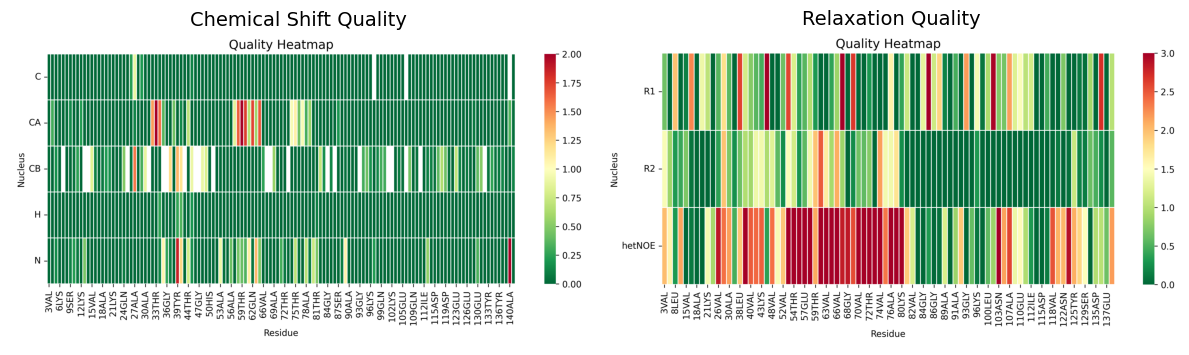

asyn [['replica_04_DESAMBER_md_2000ns.xtc']]


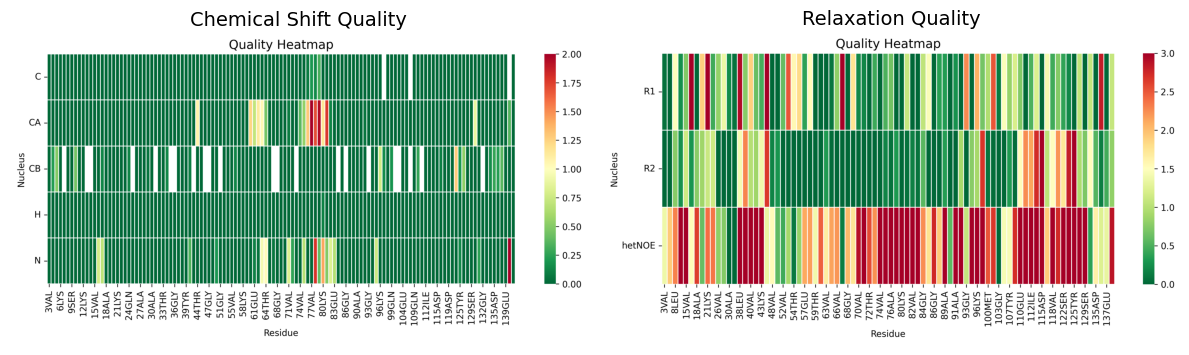

asyn [['replica_04_CHARMM36M_md_2000ns.xtc']]


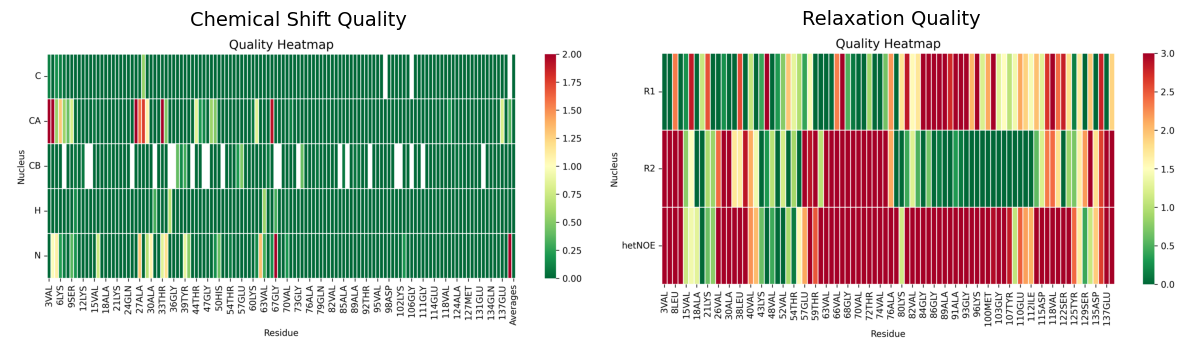

asyn [['replica_01_DESAMBER_md_2000ns.xtc']]


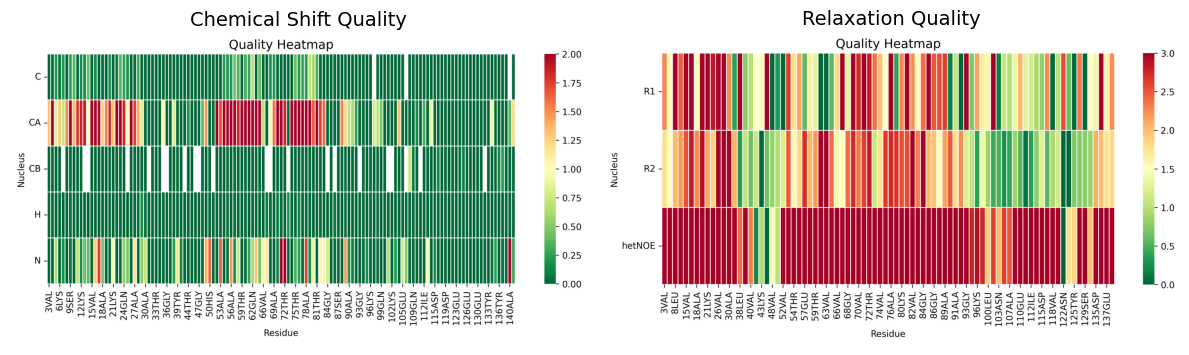

asyn [['replica_03_DESAMBER_md_2000ns.xtc']]


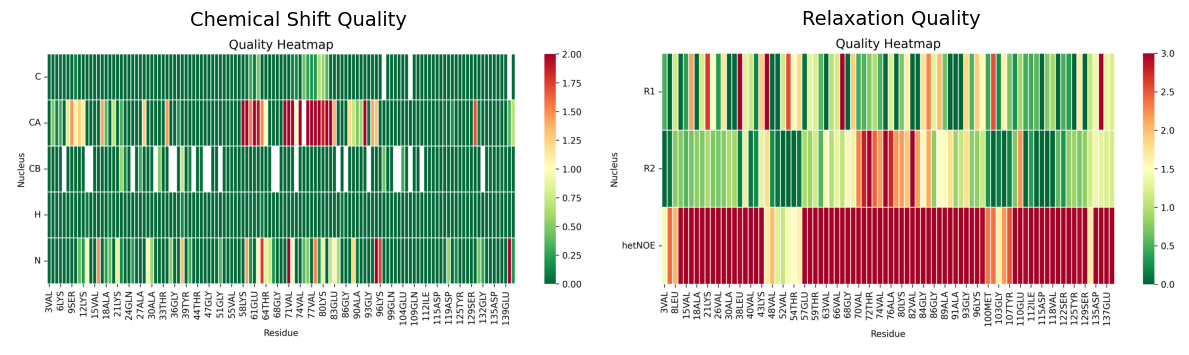

asyn [['replica_05_CHARMM36M_md_2000ns.xtc']]


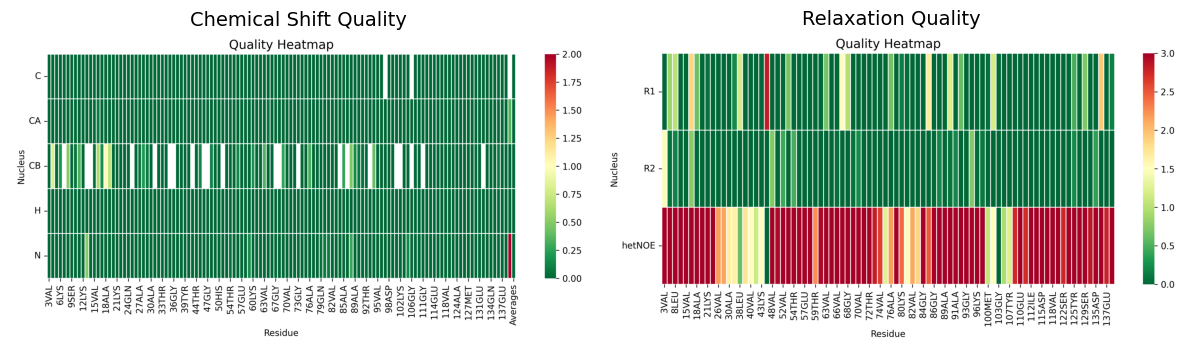

asyn [['replica_01_CHARMM36M_md_2000ns.xtc']]


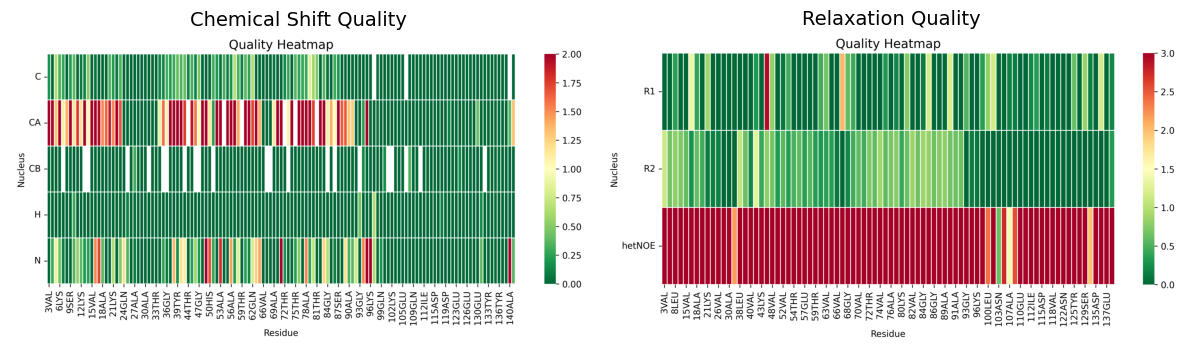

asyn [['replica_04_AMBER99SB-DISP_md_2000ns.xtc']]


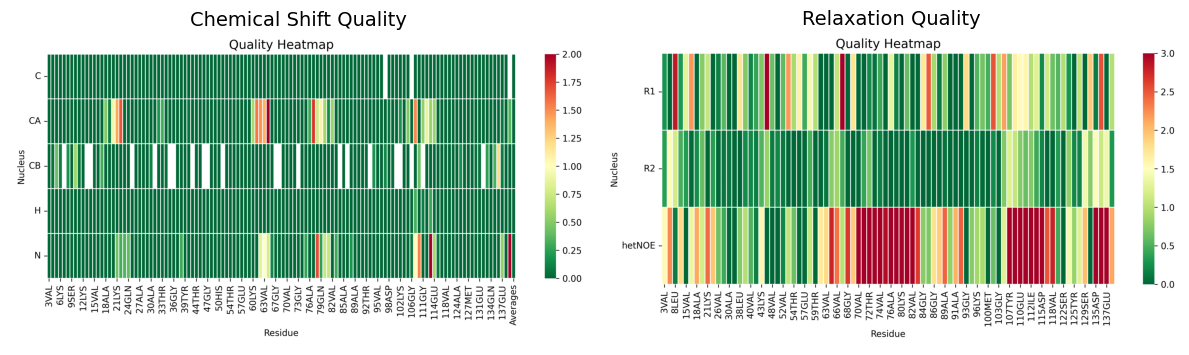

asyn [['replica_01_AMBER99SB-DISP_md_2000ns.xtc']]


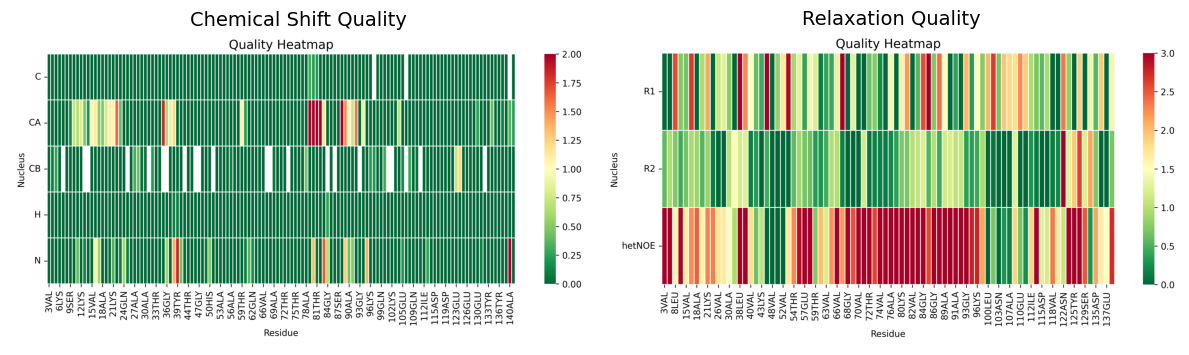

asyn [['replica_05_AMBER99SB-DISP_md_2000ns.xtc']]


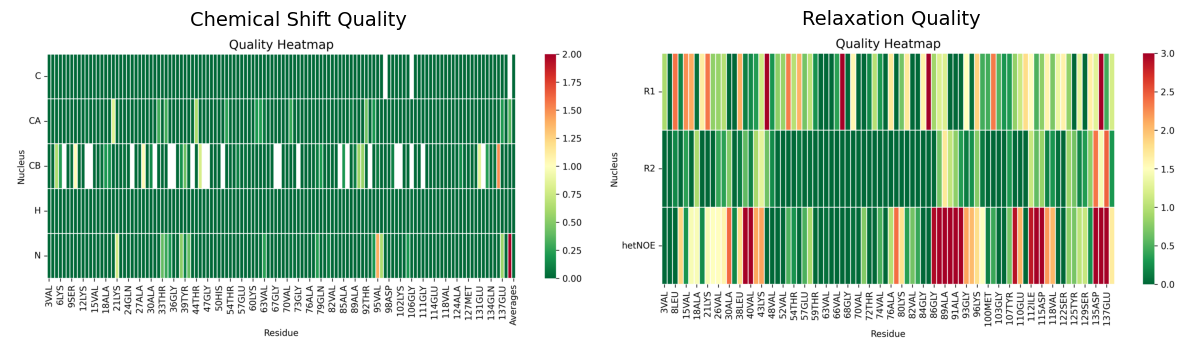

asyn [['replica_04_AMBER99SBWS_md_2000ns.xtc']]


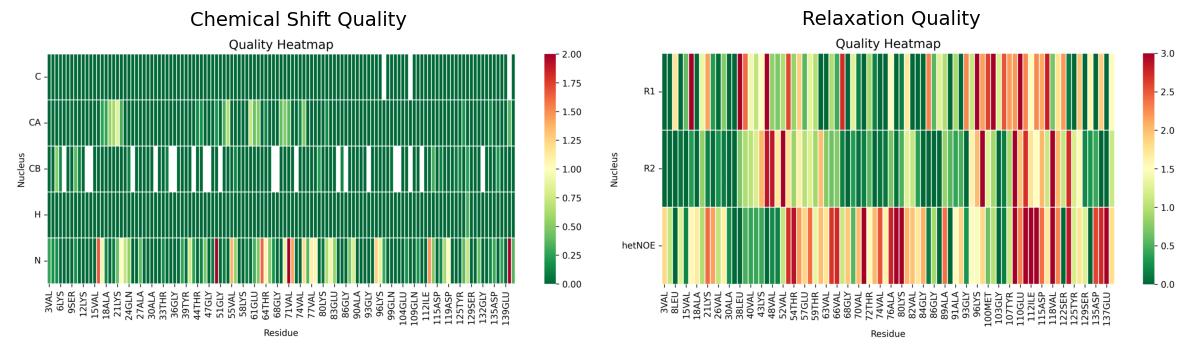

asyn [['replica_02_CHARMM36M_md_2000ns.xtc']]


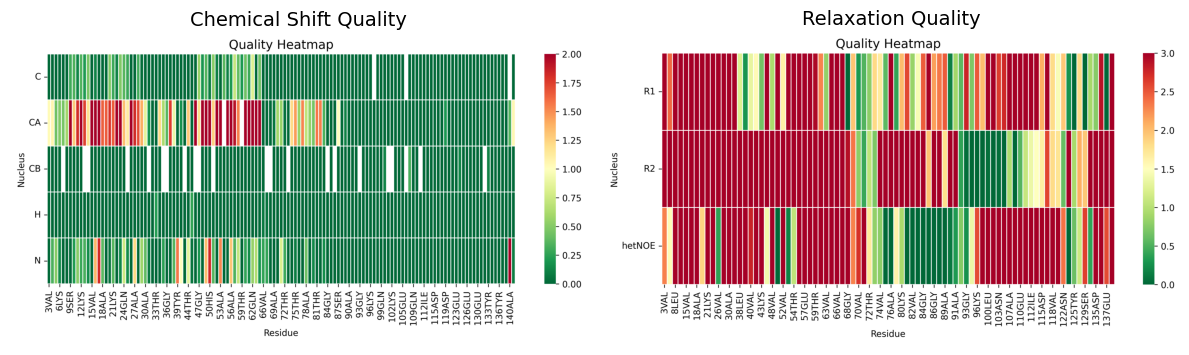

asyn [['replica_05_DESAMBER_md_2000ns.xtc']]


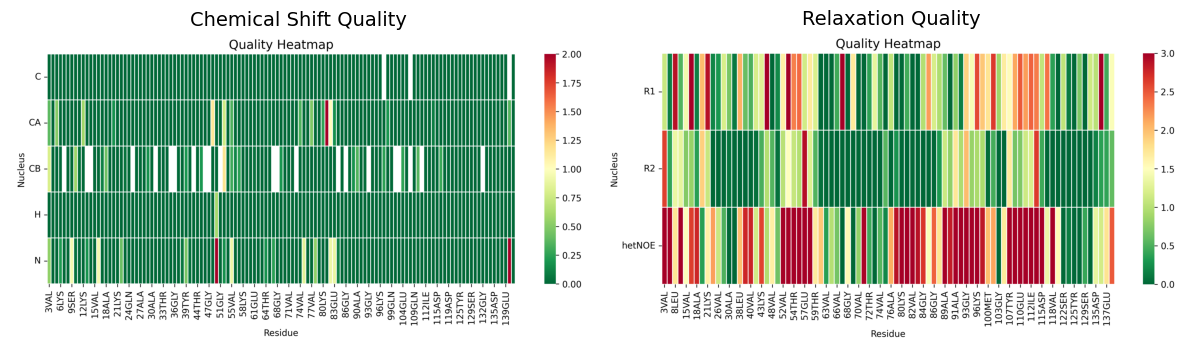

asyn [['replica_01_AMBER99SBWS_md_2000ns.xtc']]


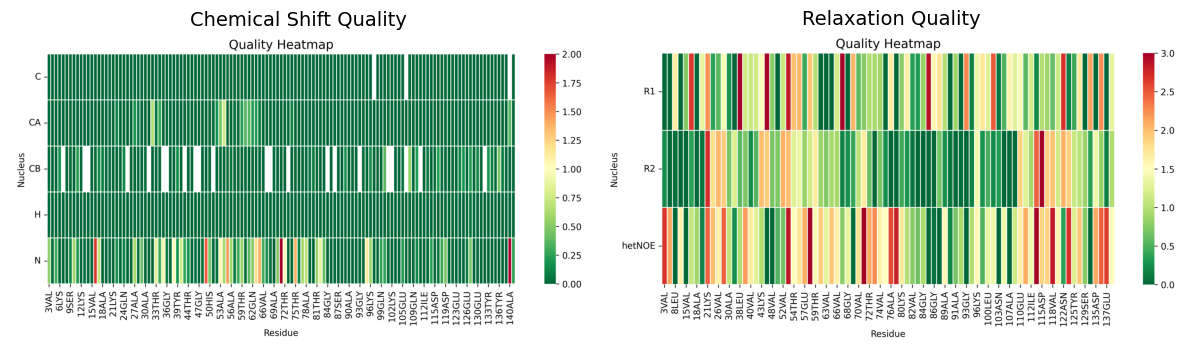

asyn [['replica_02_AMBER99SBWS_md_2000ns.xtc']]


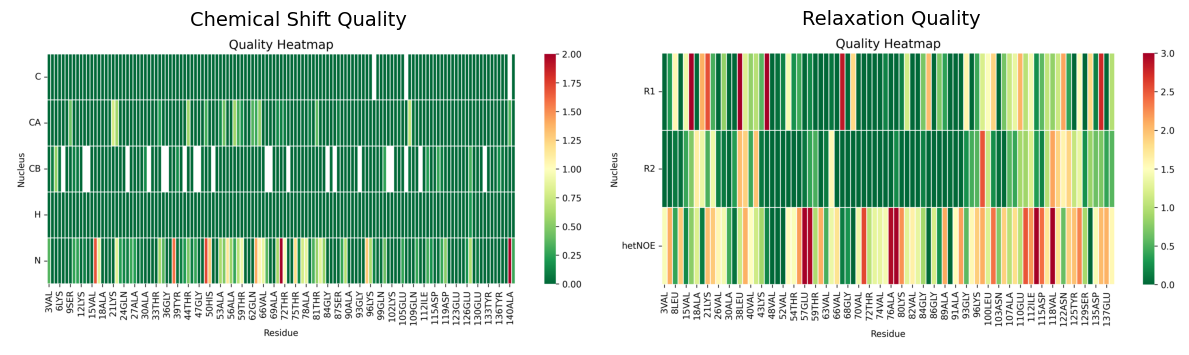

asyn [['replica_04_AMBER03WS_md_2000ns.xtc']]


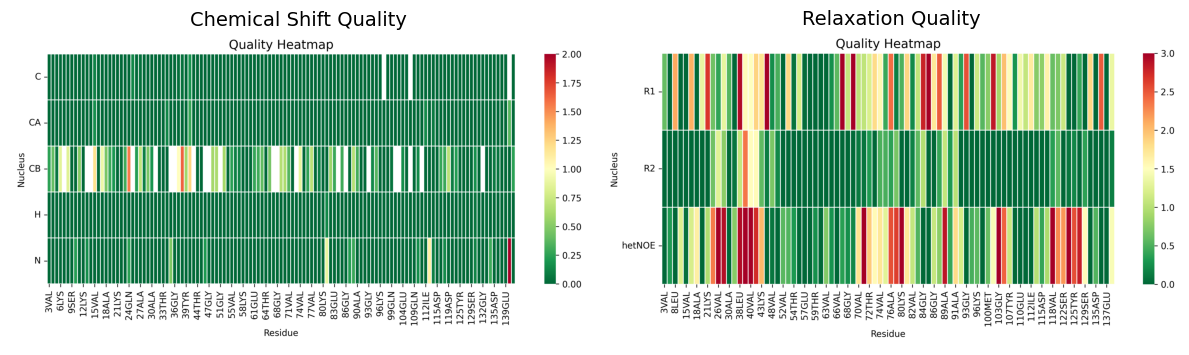

asyn [['replica_03_AMBER03WS_md_2000ns.xtc']]


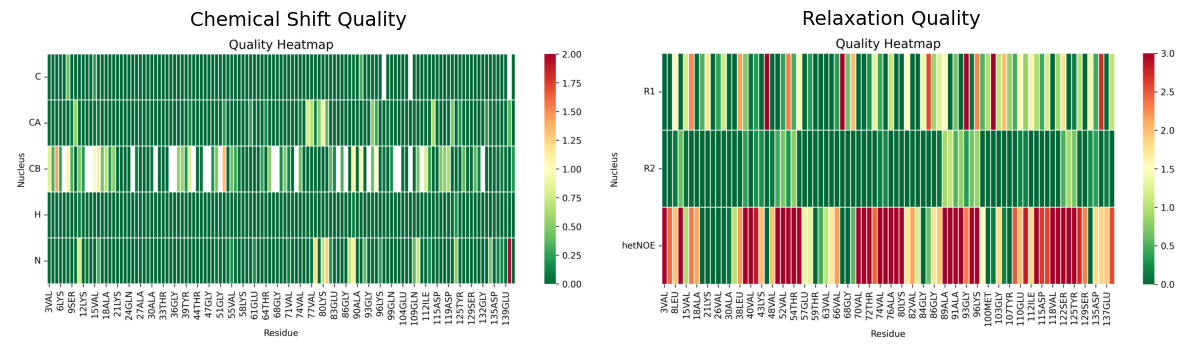

asyn [['replica_03_CHARMM36M_md_2000ns.xtc']]


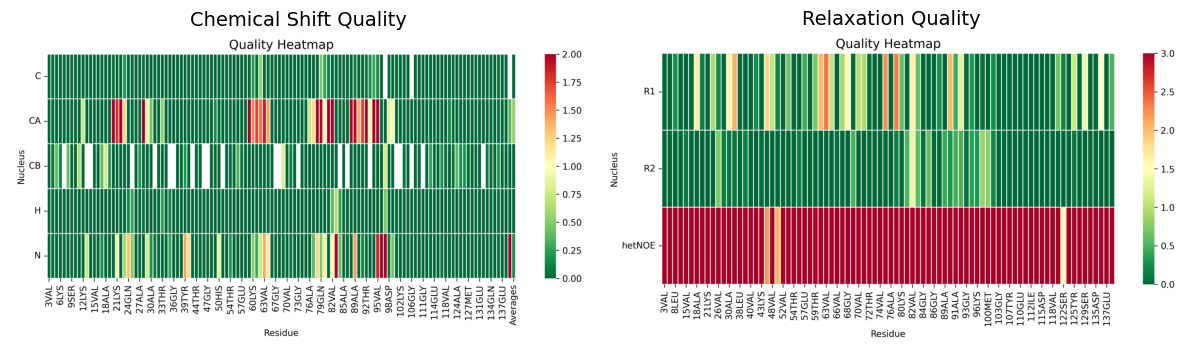

asyn [['replica_03_AMBER99SB-DISP_md_2000ns.xtc']]


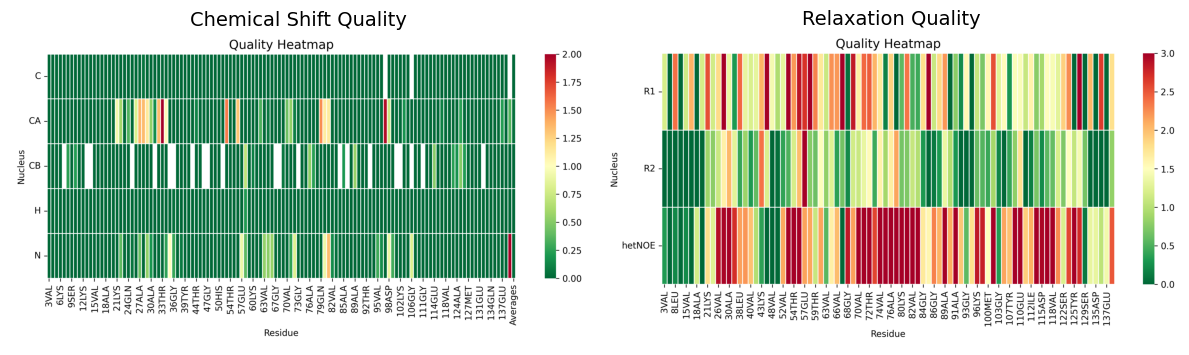

asyn [['replica_05_AMBER99SBWS_md_2000ns.xtc']]


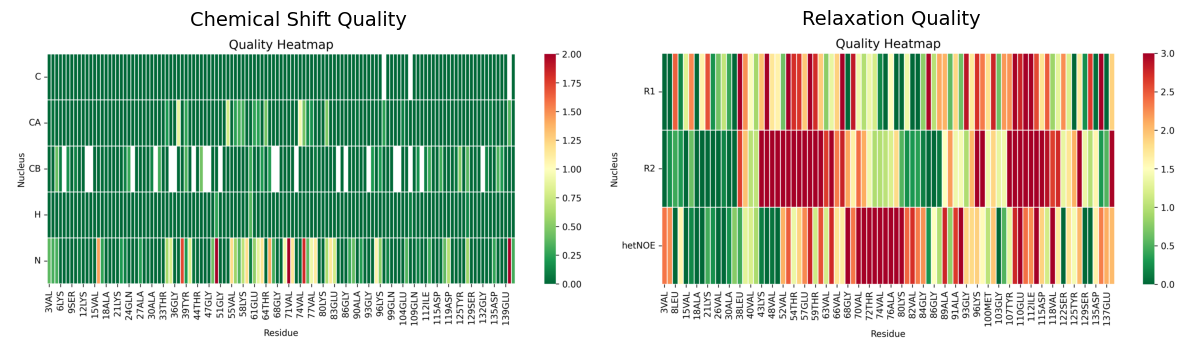

asyn [['replica_01_AMBER03WS_md_2000ns.xtc']]


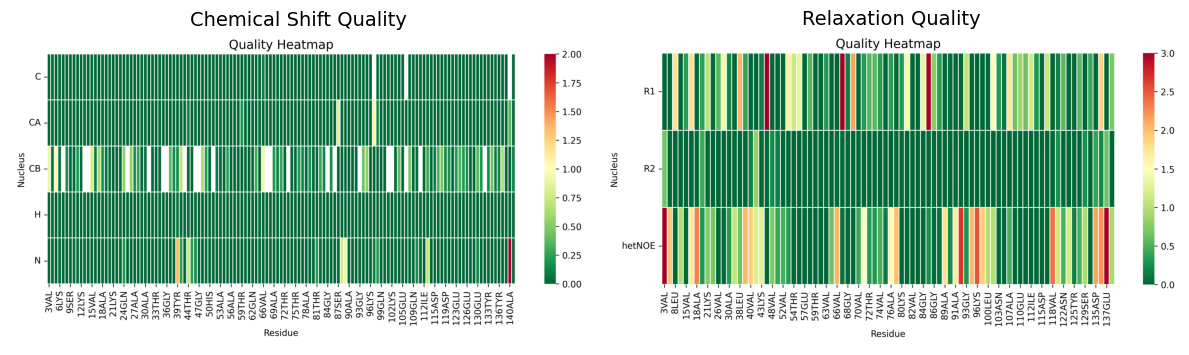

asyn [['replica_03_AMBER99SBWS_md_2000ns.xtc']]


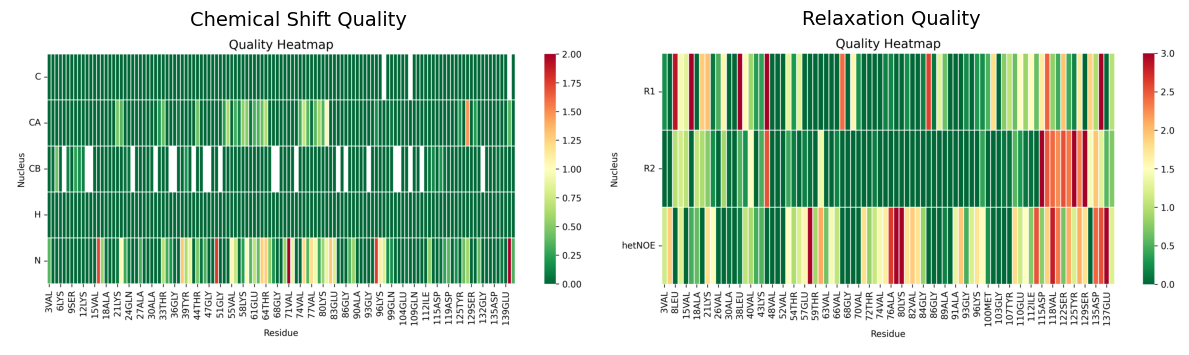

asyn [['replica_02_AMBER99SB-DISP_md_2000ns.xtc']]


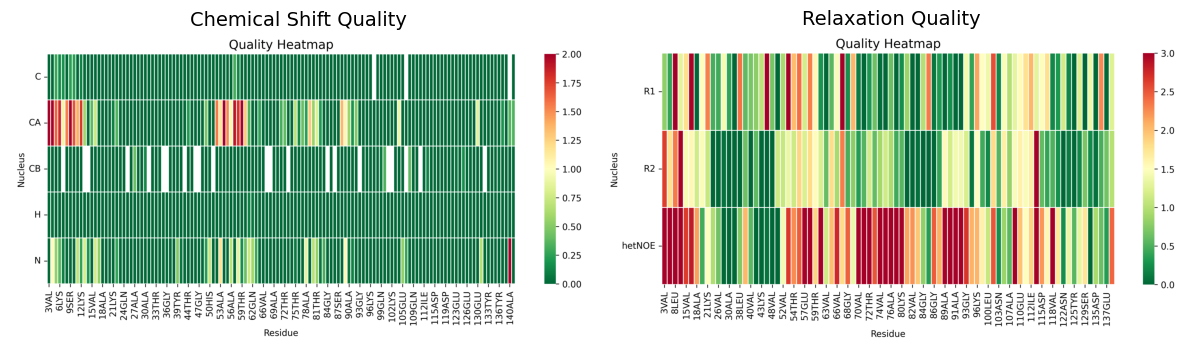

asyn [['replica_05_AMBER03WS_md_2000ns.xtc']]


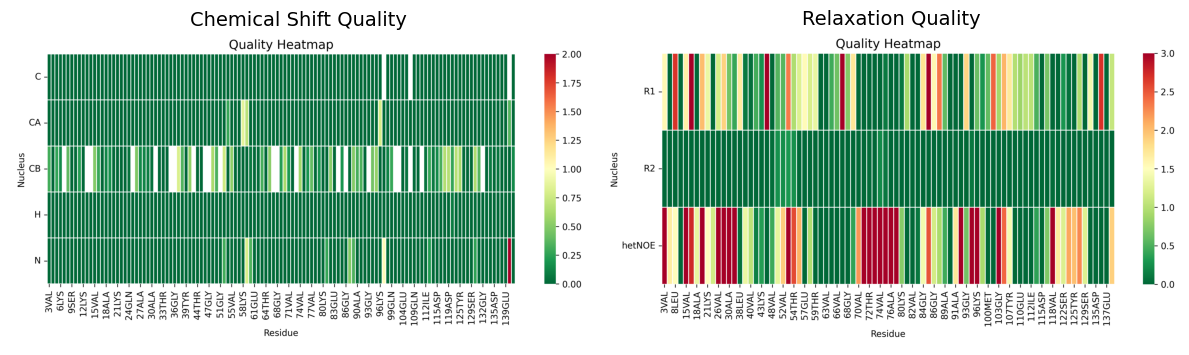

asyn [['replica_02_DESAMBER_md_2000ns.xtc']]


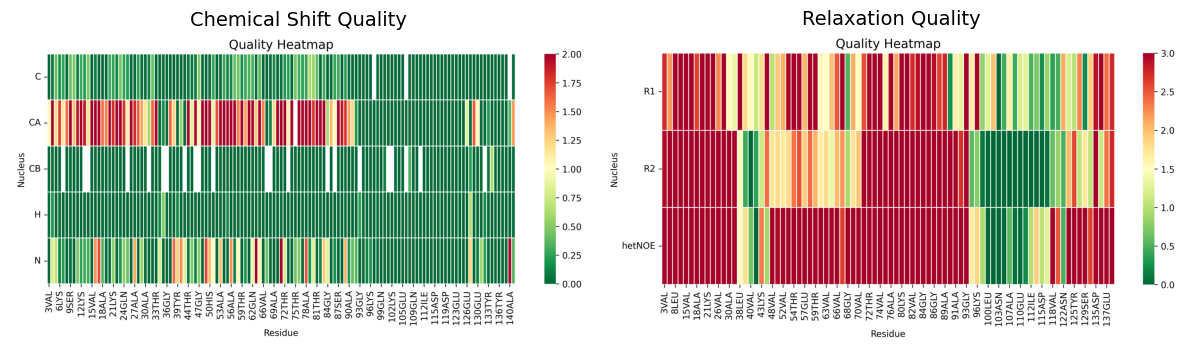

In [86]:
for system in systems:
    if 'asyn' not in system['SYSTEM']:
        continue
    print(system['SYSTEM'], system['TRJ'])
    dataFolder = '../../Data/Simulations/' + system['path']
    # Paths
    chem_path = dataFolder + 'chemical_shift_quality_heatmap.png'
    relax_path = dataFolder + 'relaxation_quality_heatmap.png'

    # Load images
    img1 = plt.imread(chem_path)
    img2 = plt.imread(relax_path)

    # Create side-by-side plot
    fig, axes = plt.subplots(1, 2, figsize=(12, 6))

    # Chemical shift heatmap
    axes[0].imshow(img1)
    axes[0].set_title("Chemical Shift Quality", fontsize=14)
    axes[0].axis("off")

    # Relaxation heatmap
    axes[1].imshow(img2)
    axes[1].set_title("Relaxation Quality", fontsize=14)
    axes[1].axis("off")

    plt.tight_layout()
    plt.show()



In [49]:
import numpy as np

def compute_rmsd_between_files(file1, file2):
    """
    Compute RMSD between the second-column values of two text files,
    aligning by the first-column index (e.g., residue/frame number).

    Works even if files have missing rows or different formats.
    """

    def load_index_value_map(filename):
        data = {}
        with open(filename) as f:
            for line in f:
                parts = line.strip().split()
                if len(parts) < 2:
                    continue
                try:
                    idx = int(float(parts[0]))
                    val = float(parts[1])
                    if np.isfinite(val):
                        data[idx] = val
                except ValueError:
                    continue
        return data

    data1 = load_index_value_map(file1)
    data2 = load_index_value_map(file2)

    # Find common indices
    common_indices = sorted(set(data1.keys()) & set(data2.keys()))
    if not common_indices:
        print("⚠️ No overlapping indices found between files.")
        return None

    vals1 = np.array([data1[i] for i in common_indices])
    vals2 = np.array([data2[i] for i in common_indices])

    rmsd = np.sqrt(np.mean((vals1 - vals2) ** 2))

    print(f"✅ Compared {len(common_indices)} common indices.")
    return rmsd


In [47]:
file1 = '/home/sosamuli/Dropbox/TonB/Data/T2fromSmulationsTIP4P_T303K.dat'
file2 = '/home/sosamuli/Dropbox/TonB/Data/experimentalRELAXATIONdata/T2experimentalDATA850MHz.dat'
compute_rmsd_between_files(file1, file2)

✅ Compared 79 common indices.


3.8338524741206323

In [50]:
file1 = '/home/sosamuli/Dropbox/TonB/Data/NOEfromSmulationsTIP4P_303K.dat'
file2 = '/home/sosamuli/Dropbox/TonB/Data/experimentalRELAXATIONdata/15N-NOEexperimentalDATA850MHz.dat'
compute_rmsd_between_files(file1, file2)

✅ Compared 84 common indices.


0.10612276830024654

In [78]:
import os
import re
import matplotlib.pyplot as plt

# Fixed order of force fields
FF_ORDER = ["AMBER03WS", "AMBER99SB-DISP", "AMBER99SBWS", "DESAMBER", "CHARMM36M"]

def extract_ff_and_replica(trj_name):
    """Extract force field and replica number from trajectory filename."""
    match_ff = re.search(r"(AMBER03WS|AMBER99SB-DISP|AMBER99SBWS|DESAMBER|CHARMM36M)", trj_name.upper())
    match_rep = re.search(r"replica_(\d+)", trj_name)
    ff = match_ff.group(1) if match_ff else "UNKNOWN"
    replica = int(match_rep.group(1)) if match_rep else 0
    return ff, replica


def plot_heatmaps(systems, plot_type="chemical_shift", save_path=None):
    """
    Create a heatmap grid for either chemical shifts or relaxation data.

    Parameters
    ----------
    systems : list of dict
        Simulation system metadata.
    plot_type : str
        Either "chemical_shift" or "relaxation".
    save_path : str or None
        If provided, saves the figure instead of displaying it.
    """
    assert plot_type in ["chemical_shift", "relaxation"], "Invalid plot type"

    # --- Organize systems by force field and replica ---
    systems_by_ff = {ff: {} for ff in FF_ORDER}
    for system in systems:
        if 'asyn' not in system.get('SYSTEM', ''):
            continue
        trj_name = system['TRJ'][0][0]
        ff, replica = extract_ff_and_replica(trj_name)
        if ff in systems_by_ff:
            systems_by_ff[ff][replica] = system

    # --- Determine layout ---
    all_replicas = sorted({rep for ff_data in systems_by_ff.values() for rep in ff_data.keys()})
    n_rows = len(all_replicas)
    n_cols = len(FF_ORDER)

    # --- Create figure ---
    fig, axes = plt.subplots(
        nrows=n_rows,
        ncols=n_cols,
        figsize=(4 * n_cols, 2.5 * n_rows),
    )

    if n_rows == 1:
        axes = [axes]  # handle single-row case

    for col, ff in enumerate(FF_ORDER):
        for row_idx, replica in enumerate(all_replicas):
            ax = axes[row_idx][col]
            ax.axis("off")

            system = systems_by_ff[ff].get(replica)
            if system:
                dataFolder = os.path.join('../../Data/Simulations', system['path'])
                filename = f"{plot_type}_quality_heatmap.png"
                path = os.path.join(dataFolder, filename)
                if os.path.exists(path):
                    img = plt.imread(path)
                    ax.imshow(img)

            # Titles and labels
            if row_idx == 0:
                ax.set_title(ff, fontsize=12, pad=10)
            if col == 0:
                ax.set_ylabel(f"Replica {replica}", fontsize=10, rotation=0, labelpad=35, va='center')

    # --- Figure title ---
    fig.suptitle(
        "Chemical Shift Quality Heatmaps" if plot_type == "chemical_shift"
        else "Spin Relaxation Quality Heatmaps",
        fontsize=16,
        y=1.02
    )

    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches="tight")
        plt.close(fig)
    else:
        plt.show()


# Example usage:
# plot_heatmaps(systems, plot_type="chemical_shift", save_path="chemical_shift_grid.png")
# plot_heatmaps(systems, plot_type="relaxation", save_path="relaxation_grid.png")


In [87]:
plot_heatmaps(systems, plot_type="chemical_shift", save_path="chemical_shift_grid.png")
plot_heatmaps(systems, plot_type="relaxation", save_path="relaxation_grid.png")